# Xarray-Spatial GLCM: Texture metrics for raster classification

Gray-Level Co-occurrence Matrix (GLCM) features capture spatial patterns that spectral bands alone cannot distinguish. They quantify how pixel intensities co-occur within a neighborhood, producing metrics like contrast, homogeneity, and entropy. This notebook covers the six Haralick features available in `glcm_texture`, parameter tuning, and a satellite-based water/land classification example.

### What you'll build

1. Create a synthetic raster with four distinct texture quadrants
2. Compute a single GLCM metric (contrast)
3. Compute all six metrics at once
4. Explore the effect of pixel-pair angle on directional textures
5. Run GLCM on chunked Dask arrays
6. Classify water vs. land on a Sentinel-2 NIR band using GLCM features and KMeans

![GLCM texture preview](images/glcm_texture_preview.png)

**Jump to a section:**
[Single metric](#Single-metric) | [All metrics](#All-metrics) | [Angle effect](#Angle-effect) | [Dask support](#Dask-support) | [Satellite classification](#Satellite-classification)

Standard imports plus `glcm_texture` from xrspatial.

In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

from xrspatial import glcm_texture

## Synthetic test raster

Four quadrants with distinct textures: smooth gradient (top-left), random noise (top-right), vertical stripes (bottom-left), and checkerboard (bottom-right). GLCM metrics should separate these regions cleanly.

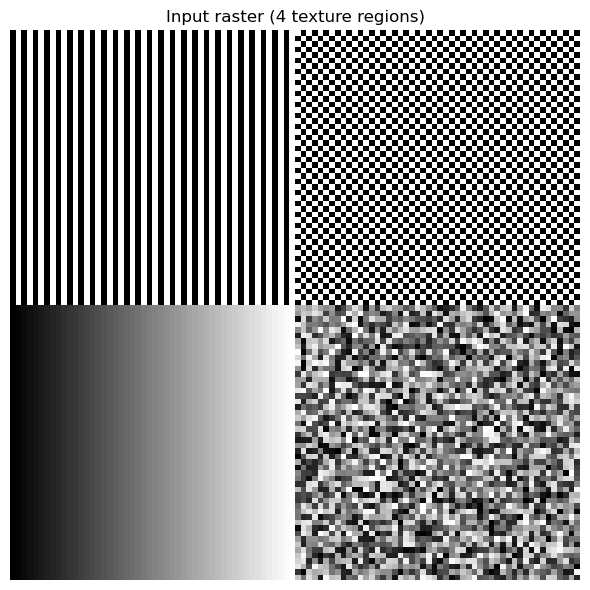

In [2]:
rng = np.random.default_rng(42)
data = np.zeros((100, 100), dtype=np.float64)

data[:50, :50] = np.linspace(0, 1, 50)[np.newaxis, :]      # smooth gradient
data[:50, 50:] = rng.random((50, 50))                        # random noise
data[50:, :50] = np.tile([0.0, 1.0], 25)[np.newaxis, :]     # vertical stripes
cb = np.zeros((50, 50))
cb[::2, 1::2] = 1.0
cb[1::2, ::2] = 1.0
data[50:, 50:] = cb                                           # checkerboard

agg = xr.DataArray(data, dims=['y', 'x'],
                   coords={'y': np.arange(100, dtype=float),
                           'x': np.arange(100, dtype=float)})

fig, ax = plt.subplots(figsize=(6, 6))
agg.plot.imshow(ax=ax, cmap='gray', add_colorbar=False)
ax.set_title('Input raster (4 texture regions)')
ax.set_axis_off()
plt.tight_layout()

## Single metric

Pass a single metric name to get a 2-D result. Contrast measures the intensity difference between neighboring pixels, so noisy and patterned regions score high while smooth regions score low.

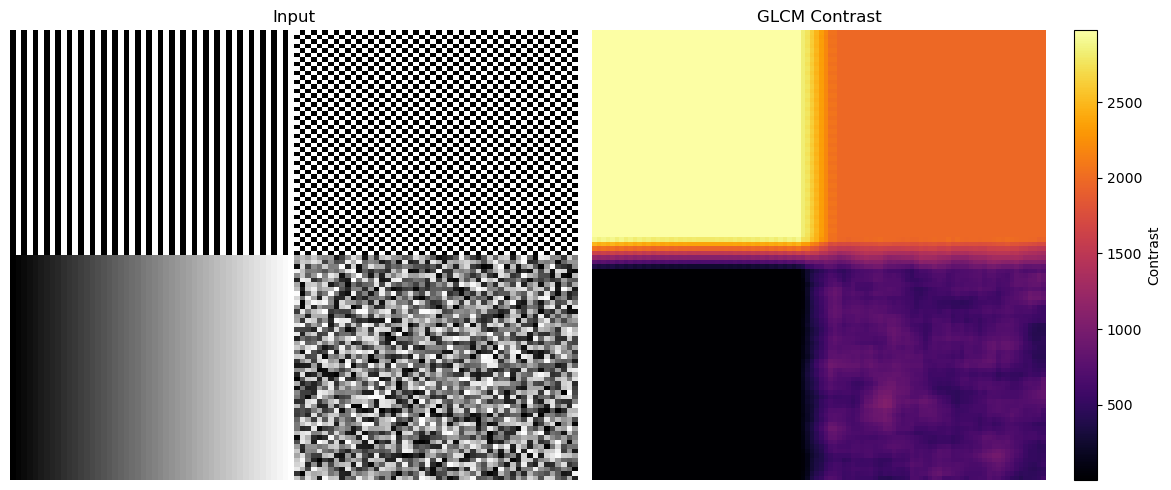

In [3]:
contrast = glcm_texture(agg, metric='contrast', window_size=7, levels=64)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

agg.plot.imshow(ax=axes[0], cmap='gray', add_colorbar=False)
axes[0].set_title('Input')
axes[0].set_axis_off()

contrast.plot.imshow(ax=axes[1], cmap='inferno', add_colorbar=True,
                     cbar_kwargs={'label': 'Contrast'})
axes[1].set_title('GLCM Contrast')
axes[1].set_axis_off()

plt.tight_layout()

## All metrics

Pass a list of metric names to get a 3-D result with a leading `metric` dimension. This is more efficient than separate calls because the GLCM is built once per window position.

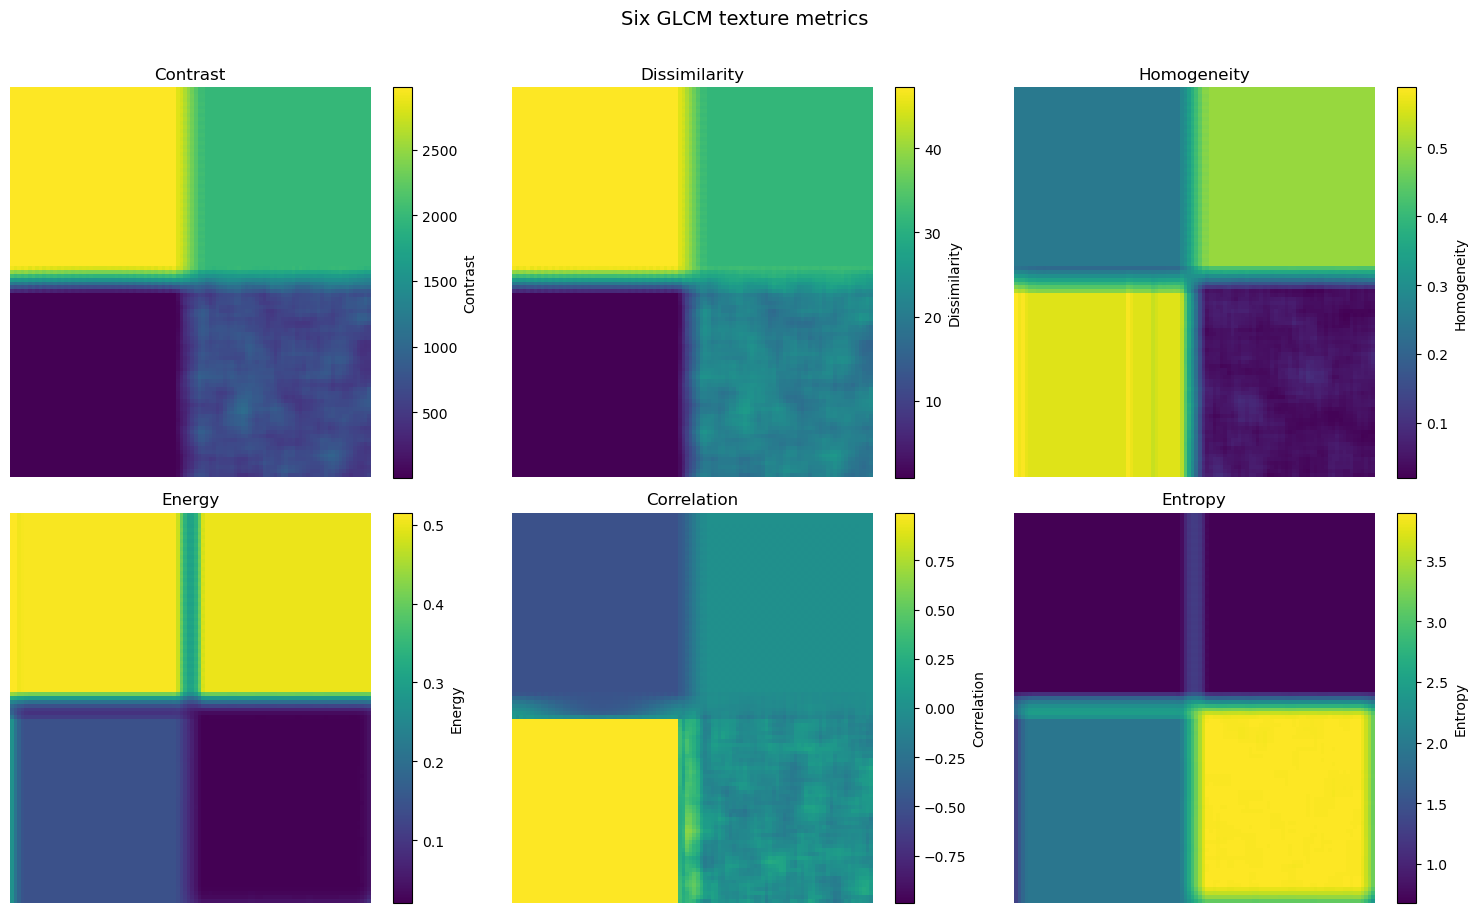

In [4]:
metrics = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'entropy']
textures = glcm_texture(agg, metric=metrics, window_size=7, levels=64)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, name in zip(axes.flat, metrics):
    textures.sel(metric=name).plot.imshow(ax=ax, cmap='viridis', add_colorbar=True,
                                          cbar_kwargs={'label': name.capitalize()})
    ax.set_title(name.capitalize())
    ax.set_axis_off()

plt.suptitle('Six GLCM texture metrics', fontsize=14, y=1.01)
plt.tight_layout()

# Save preview image
import pathlib
pathlib.Path('images').mkdir(exist_ok=True)
fig.savefig('images/glcm_texture_preview.png', bbox_inches='tight', dpi=120)

## Angle effect

The `angle` parameter controls the direction of pixel pairing: 0 (horizontal), 45 (diagonal), 90 (vertical), or 135 (opposite diagonal). The default (`None`) averages all four. Directional textures like stripes respond differently depending on the angle.

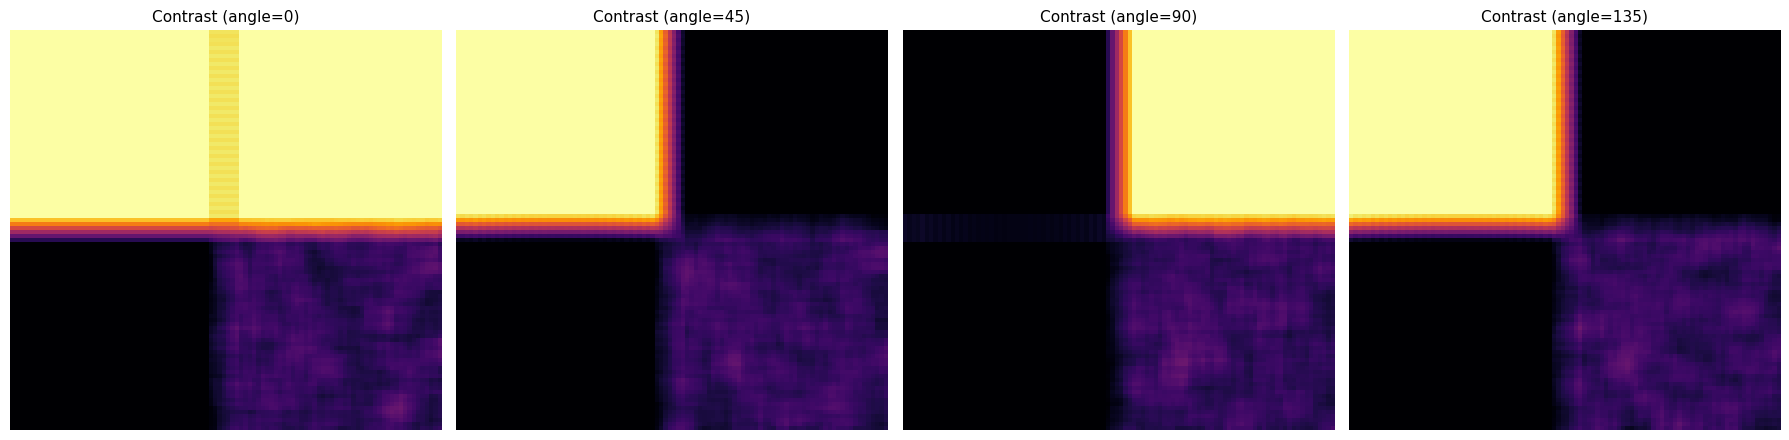

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, ang in zip(axes, [0, 45, 90, 135]):
    result = glcm_texture(agg, metric='contrast', window_size=7,
                          levels=64, angle=ang)
    result.plot.imshow(ax=ax, cmap='inferno', add_colorbar=False)
    ax.set_title(f'Contrast (angle={ang})', fontsize=11)
    ax.set_axis_off()

plt.tight_layout()

## Dask support

`glcm_texture` works on chunked Dask arrays without code changes. The input is quantized globally so gray-level mapping stays consistent across chunks, then each chunk computes features independently via `map_overlap`.

In [6]:
import dask.array as da

dask_agg = xr.DataArray(
    da.from_array(data, chunks=(50, 50)),
    dims=['y', 'x'],
)

dask_contrast = glcm_texture(dask_agg, metric='contrast',
                             window_size=7, levels=64)
print(f'Result type: {type(dask_contrast.data)}')
print(f'Chunks: {dask_contrast.data.chunks}')

# Verify it matches the numpy result
np.testing.assert_allclose(
    contrast.values, dask_contrast.values,
    rtol=1e-10, equal_nan=True,
)
print('Dask result matches numpy result.')

Result type: <class 'dask.array.core.Array'>
Chunks: ((50, 50), (50, 50))
Dask result matches numpy result.


<div class="alert alert-block alert-warning">
<b>Gray levels vs. precision.</b> The <code>levels</code> parameter quantizes the input before building the co-occurrence matrix. Lower values (16-32) run faster but lose tonal detail. Higher values (128-256) preserve detail but increase memory and computation. For 8-bit imagery, <code>levels=64</code> is usually a good balance.
</div>

## Satellite classification

The synthetic quadrants above make the math obvious, but the real payoff is on actual imagery. Water and land have very different spatial textures in satellite data: water is smooth and uniform, land is rough and varied. GLCM features capture that difference even when raw pixel brightness is ambiguous (shadows, mudflats, dark pavement).

Below we grab a Sentinel-2 NIR band, compute GLCM features, and use KMeans clustering to classify water vs. land without any training labels.

### Step 1 — Download a Sentinel-2 NIR band

We read a 500 x 500 pixel window (5 km x 5 km at 10 m resolution) straight from a
Cloud-Optimized GeoTIFF hosted on AWS. The scene is
[S2B_10SEG_20230921](https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/10/S/EG/2023/9/S2B_10SEG_20230921_0_L2A/),
a near-cloudless capture of the Bay Area from September 2023.

If the remote file is unreachable, a synthetic coastal raster is used instead
so the rest of the notebook still runs.

Downloaded NIR band: (500, 500), range 0 to 9224


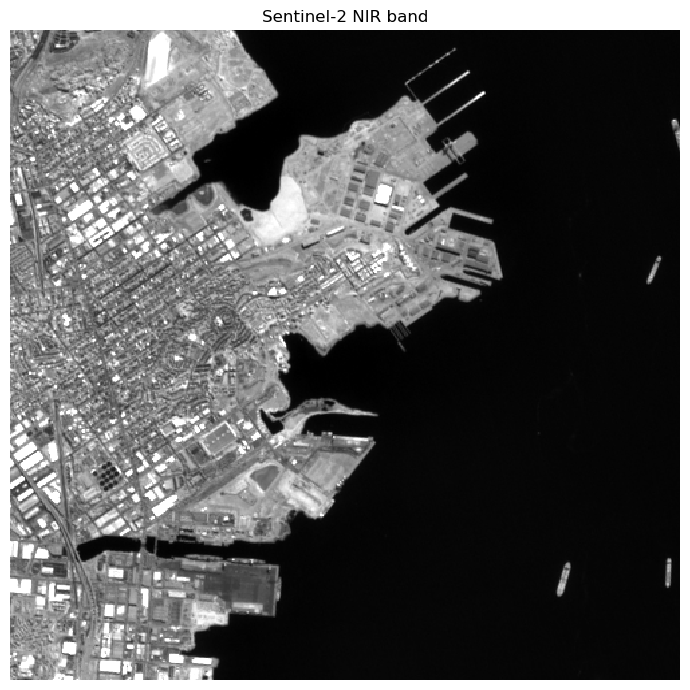

In [7]:
import os
import rioxarray

os.environ['AWS_NO_SIGN_REQUEST'] = 'YES'
os.environ['GDAL_DISABLE_READDIR_ON_OPEN'] = 'EMPTY_DIR'

COG_URL = (
    'https://sentinel-cogs.s3.us-west-2.amazonaws.com/'
    'sentinel-s2-l2a-cogs/10/S/EG/2023/9/'
    'S2B_10SEG_20230921_0_L2A/B08.tif'
)

try:
    nir_da = rioxarray.open_rasterio(COG_URL).isel(band=0, y=slice(2100, 2600), x=slice(5300, 5800))
    nir = nir_da.load().values.astype(np.float64)
    print(f'Downloaded NIR band: {nir.shape}, range {nir.min():.0f} to {nir.max():.0f}')
except Exception as exc:
    print(f'Remote read failed ({exc}), using synthetic fallback')
    rng_sat = np.random.default_rng(99)
    nir = np.zeros((500, 500), dtype=np.float64)
    nir[:, 250:] = rng_sat.normal(80, 10, (500, 250)).clip(20, 200)
    nir[:, :250] = rng_sat.normal(1800, 400, (500, 250)).clip(300, 4000)

satellite = xr.DataArray(nir, dims=['y', 'x'],
                         coords={'y': np.arange(nir.shape[0], dtype=float),
                                 'x': np.arange(nir.shape[1], dtype=float)})

fig, ax = plt.subplots(figsize=(7, 7))
satellite.plot.imshow(ax=ax, cmap='gray', vmax=float(np.percentile(nir, 98)),
                      add_colorbar=False)
ax.set_title('Sentinel-2 NIR band')
ax.set_axis_off()
plt.tight_layout()

### Step 2 — Compute GLCM texture features

We pick four metrics that tend to separate water (uniform, high energy, high homogeneity) from land (rough, high contrast):

| Metric | Water (smooth) | Land (rough) |
|---|---|---|
| contrast | low | high |
| homogeneity | high | low |
| energy | high | low |
| correlation | high (uniform) | lower (varied) |

An 11 x 11 window gives enough spatial context at 10 m resolution (110 m footprint).

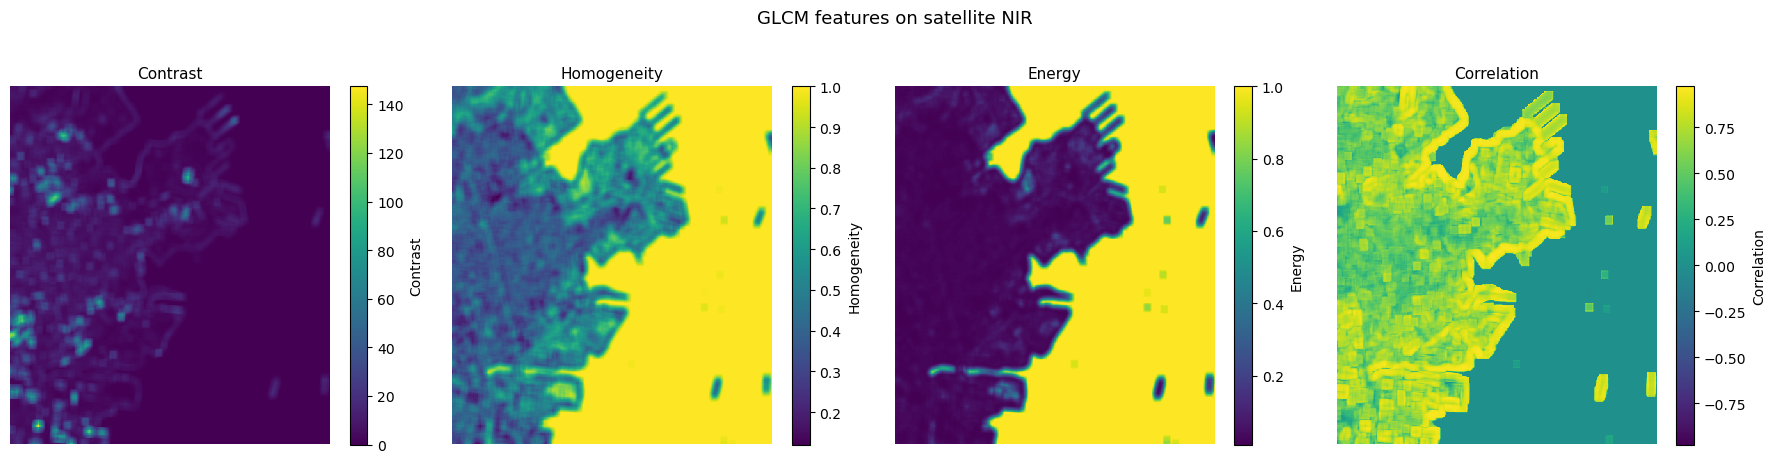

In [8]:
sat_metrics = ['contrast', 'homogeneity', 'energy', 'correlation']
sat_textures = glcm_texture(satellite, metric=sat_metrics, window_size=11, levels=64)

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, name in zip(axes, sat_metrics):
    sat_textures.sel(metric=name).plot.imshow(ax=ax, cmap='viridis', add_colorbar=True,
                                              cbar_kwargs={'label': name.capitalize()})
    ax.set_title(name.capitalize(), fontsize=11)
    ax.set_axis_off()

plt.suptitle('GLCM features on satellite NIR', fontsize=13, y=1.02)
plt.tight_layout()

Stack the four texture layers into a feature vector per pixel, normalize, and let KMeans find two clusters. No training labels needed. After clustering, the cluster with lower mean NIR reflectance is labeled "water."

In [9]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Stack texture features: (H, W, 4)
feature_stack = np.stack(
    [sat_textures.sel(metric=m).values for m in sat_metrics], axis=-1
)
h, w, n_feat = feature_stack.shape

# Mask out NaN edges left by the GLCM window
valid = ~np.any(np.isnan(feature_stack), axis=-1)
X = feature_stack[valid]

# Normalize and cluster
X_scaled = StandardScaler().fit_transform(X)
labels = KMeans(n_clusters=2, random_state=42, n_init=10).fit_predict(X_scaled)

# Build the classification raster
class_map = np.full((h, w), np.nan)
class_map[valid] = labels

# Assign "water" to the cluster with lower NIR reflectance
cluster_nir = [np.nanmean(nir[class_map == c]) for c in range(2)]
water_id = int(np.argmin(cluster_nir))

water_mask = np.where(valid, class_map == water_id, np.nan)
print(f'Water cluster: {water_id} (mean NIR {cluster_nir[water_id]:.0f})')
print(f'Land  cluster: {1 - water_id} (mean NIR {cluster_nir[1 - water_id]:.0f})')

Water cluster: 1 (mean NIR 72)
Land  cluster: 0 (mean NIR 1877)


Left: NIR image (bright = land, dark = water). Right: GLCM-based classification. The shoreline comes through cleanly without any training polygons.

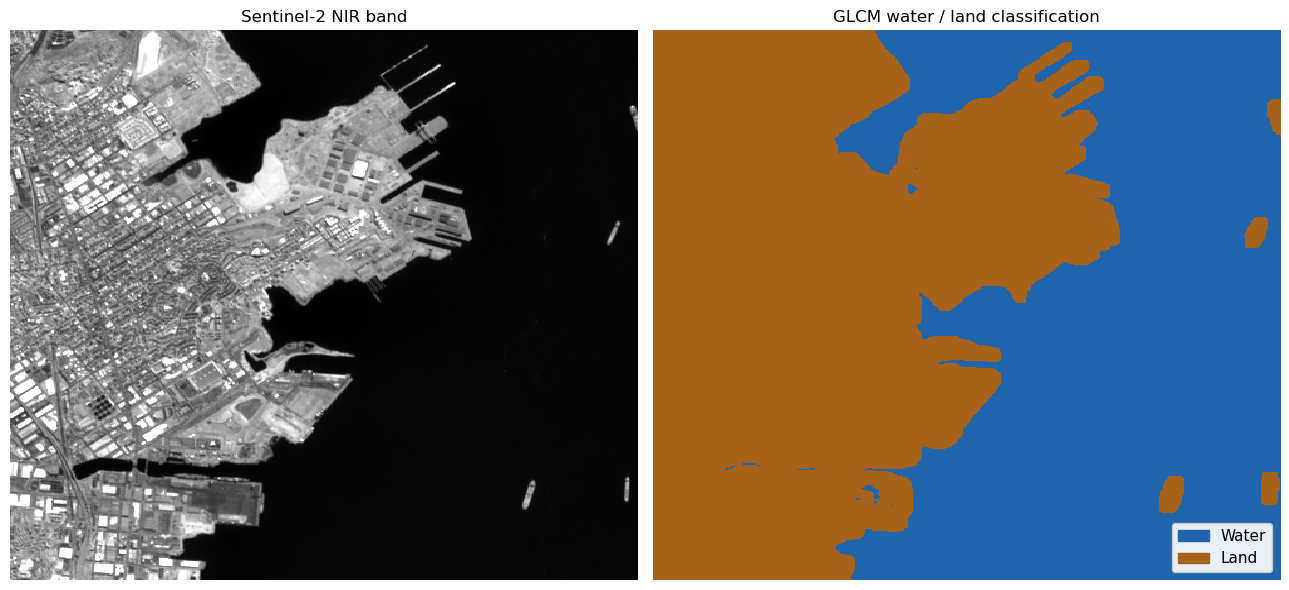

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# NIR image
satellite.plot.imshow(ax=axes[0], cmap='gray', vmax=float(np.percentile(nir, 98)),
                      add_colorbar=False)
axes[0].set_title('Sentinel-2 NIR band')
axes[0].set_axis_off()

# Classification
water_da = xr.DataArray(
    np.where(valid, (class_map == water_id).astype(float), np.nan),
    dims=['y', 'x'],
    coords={'y': np.arange(h, dtype=float), 'x': np.arange(w, dtype=float)},
)
water_cmap = ListedColormap(['#a6611a', '#2166ac'])
water_da.plot.imshow(ax=axes[1], cmap=water_cmap, vmin=0, vmax=1,
                     add_colorbar=False)
axes[1].set_title('GLCM water / land classification')
axes[1].legend(handles=[Patch(color='#2166ac', label='Water'),
                        Patch(color='#a6611a', label='Land')],
               loc='lower right', framealpha=0.9, fontsize=11)
axes[1].set_axis_off()

plt.tight_layout()

### References

- Haralick, R. M., Shanmugam, K., & Dinstein, I. (1973). [Textural Features for Image Classification](https://doi.org/10.1109/TSMC.1973.4309314). *IEEE Transactions on Systems, Man, and Cybernetics*, SMC-3(6), 610-621.
- [Gray-level co-occurrence matrix (Wikipedia)](https://en.wikipedia.org/wiki/Co-occurrence_matrix)
- [xrspatial.glcm_texture API docs](https://xarray-spatial.readthedocs.io/en/latest/reference/_autosummary/xrspatial.glcm_texture.html)